# 04 - Nonlinear Links, Nonparametric Kernels and Sparsity

The linear Hawkes model cannot represent **inhibition**: $\varphi \ge 0$ keeps
the intensity from ever being suppressed. Three tools lift these limits:

* **Nonlinear Hawkes** -- pass the summed input through a link $f$:
  $\lambda(t) = f\!\big(\mu + \sum \varphi(t-t_i)\big)$. A non-negative link
  (softplus/relu) lets signed kernels encode inhibition while keeping
  $\lambda \ge 0$.
* **Nonparametric kernels** -- estimate the kernel *shape* from data with a
  piecewise-constant $\varphi$ instead of assuming exponential/power-law.
* **Regularisation** -- L1/elastic-net penalties drive spurious connections to
  zero for sparse, interpretable graphs.

*Builds on 01-02.*

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import intensify as it

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.titlesize": 13})

rng = np.random.default_rng(0)
print(f"intensify {it.__version__}")

intensify 0.3.3


## 1. Link functions
Supported links: `"softplus"`, `"relu"`, `"sigmoid"`, `"identity"`, or any
callable. Softplus is a smooth non-negative rectifier -- the usual default.

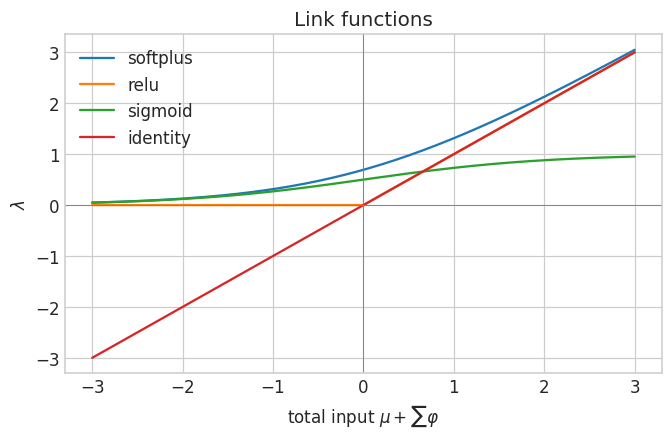

In [2]:
x = np.linspace(-3, 3, 200)
links = {"softplus": np.log1p(np.exp(x)), "relu": np.maximum(0, x),
         "sigmoid": 1 / (1 + np.exp(-x)), "identity": x}
fig, ax = plt.subplots(figsize=(7, 4))
for name, y in links.items():
    ax.plot(x, y, label=name)
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel(r"total input $\mu + \sum\varphi$"); ax.set_ylabel(r"$\lambda$")
ax.set_title("Link functions"); ax.legend(); plt.show()

## 2. Inhibition with a signed kernel
A negative $\alpha$ (allowed via `allow_signed=True`) means each event
*suppresses* the next ones -- a refractory effect. The softplus link keeps the
intensity valid even when the summed input goes negative.

In [3]:
T = 1500.0
inhib = it.NonlinearHawkes(
    mu=1.2,
    kernel=it.ExponentialKernel(alpha=-0.6, beta=2.0, allow_signed=True),
    link_function="softplus",
)
ev_inhib = np.asarray(inhib.simulate(T=T, seed=5))
print(f"{len(ev_inhib)} events; rate {len(ev_inhib)/T:.3f}/s")

res_nl = it.NonlinearHawkes(mu=1.0, kernel=it.ExponentialKernel(alpha=-0.3, beta=1.5, allow_signed=True),
                            link_function="softplus").fit(ev_inhib, T=T, method="mle")
print(res_nl.summary())
a = res_nl.flat_params()["alpha"]
print(f"\nfitted alpha = {a:.3f}  ->  {'self-inhibition' if a < 0 else 'self-excitation'}")

1608 events; rate 1.072/s


/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/kernels/exponential.py:51: RuntimeWarning: overflow encountered in exp
  return self.alpha * self.beta * np.exp(-self.beta * t)


FitResult:
  Log-likelihood: -1453.3117
  AIC: 2912.6234
  BIC: 2928.7717
  Parameters:
    mu: 1.0322020270648309
    kernel: ExponentialKernel(alpha=-0.3878659439324724, beta=2.4418808559122547, allow_signed=True)
    sigmoid_scale: 5.0
  Standard errors:
    mu: 0.0883
    alpha: 0.0738
    beta: 0.7213
  Branching ratio: 0.3879
  Endogeneity index: 0.2795

fitted alpha = -0.388  ->  self-inhibition


Inhibition regularises the spacing of events (fewer tiny intervals than
Poisson), the opposite of the excitatory clustering in notebook 01:

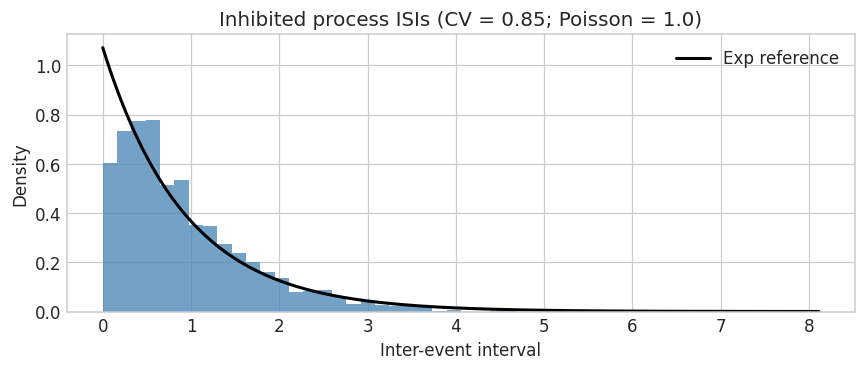

In [4]:
isi = np.diff(ev_inhib)
cv = isi.std() / isi.mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
it.plot_inter_event_intervals(ev_inhib, ax=ax, bins=50)
ax.set_title(f"Inhibited process ISIs (CV = {cv:.2f}; Poisson = 1.0)")
plt.show()

## 3. Flexible kernel shapes

A single exponential assumes one timescale. Two ways to go richer:

* **`SumExponentialKernel`** -- a sum of exponentials. It keeps the $O(N)$
  recursive likelihood, so it fits fast and can approximate multi-timescale or
  power-law-like decay. This is the recommended tool for flexible shapes.
* **`NonparametricKernel`** -- a piecewise-constant kernel that assumes *no*
  functional form. Maximally flexible, but it has no recursive form, so its
  likelihood is $O(N^2)$ and fitting is slow -- best reserved for small
  datasets or as a diagnostic. Below we build one directly to show how it
  represents an arbitrary shape.

We generate data with two excitation timescales and recover the shape with a
sum of exponentials.

In [5]:
gen = it.UnivariateHawkes(mu=0.4,
                          kernel=it.SumExponentialKernel(alphas=[0.25, 0.15], betas=[6.0, 0.8]))
ev = np.asarray(gen.simulate(T=1500.0, seed=8))
print(f"{len(ev)} events (two excitation timescales: ~0.17 s and ~1.25 s)")

# Flexible recursive fit: 3-component sum of exponentials
se = it.UnivariateHawkes(mu=0.4,
                         kernel=it.SumExponentialKernel(alphas=[0.2, 0.1, 0.05], betas=[5.0, 1.0, 0.3]))
se_res = se.fit(ev, T=1500.0, method="mle")
# Single-exponential baseline for comparison
ex_res = it.UnivariateHawkes(mu=0.4, kernel=it.ExponentialKernel(alpha=0.3, beta=1.0)).fit(ev, T=1500.0, method="mle")
print(f"{'model':<22}{'AIC':>10}")
print(f"{'single exponential':<22}{ex_res.aic:>10.1f}")
print(f"{'sum of 3 exponentials':<22}{se_res.aic:>10.1f}")
print(f"Delta AIC = {ex_res.aic - se_res.aic:.1f} (positive favours the flexible kernel)")

957 events (two excitation timescales: ~0.17 s and ~1.25 s)
model                        AIC
single exponential        2435.9
sum of 3 exponentials     2433.3
Delta AIC = 2.6 (positive favours the flexible kernel)


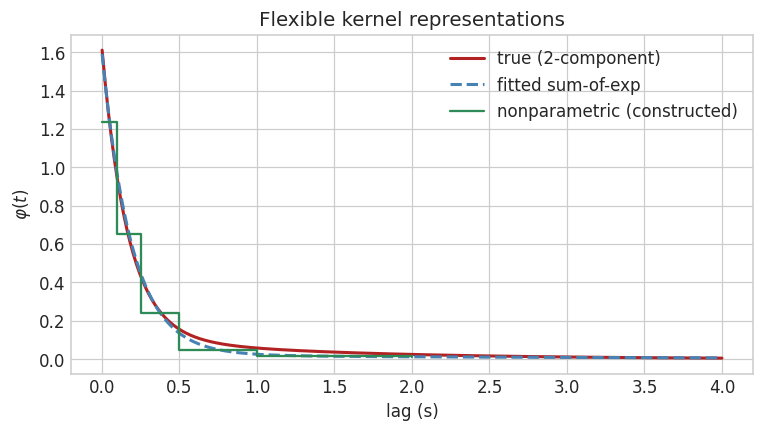

In [6]:
tg = np.linspace(1e-3, 4.0, 400)

# A NonparametricKernel built by hand: piecewise-constant approximation of the
# fitted shape (bin-averaged). This needs no fitting -- it shows the representation.
edges = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
vals = [float(se.kernel.evaluate(np.array([0.5 * (edges[i] + edges[i + 1])]))[0])
        for i in range(len(edges) - 1)]
npk = it.NonparametricKernel(edges=edges, values=vals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tg, gen.kernel.evaluate(tg), color="firebrick", lw=2, label="true (2-component)")
ax.plot(tg, se.kernel.evaluate(tg), color="steelblue", lw=2, ls="--", label="fitted sum-of-exp")
ax.step(edges[:-1], vals, where="post", color="seagreen", lw=1.5, label="nonparametric (constructed)")
ax.set_xlabel("lag (s)"); ax.set_ylabel(r"$\varphi(t)$")
ax.set_title("Flexible kernel representations"); ax.legend(); plt.show()

## 4. Sparsity: L1-penalised connectivity

In a network where most pairs are unconnected, an unpenalised fit scatters
small spurious weights everywhere. An **L1 penalty** (`regularization=`) shrinks
weak off-diagonal kernels to zero, recovering a clean graph. Pass a string
shorthand (`"l1"`) or an `it.L1(...)` / `it.ElasticNet(...)` instance.

In [7]:
N = 4
def K(a):
    return it.ExponentialKernel(alpha=a, beta=1.0)
# Sparse ground truth: a short chain 0->1->2, node 3 isolated.
mat = [[K(0.25), K(1e-6), K(1e-6), K(1e-6)],
       [K(0.40), K(0.20), K(1e-6), K(1e-6)],
       [K(1e-6), K(0.40), K(0.20), K(1e-6)],
       [K(1e-6), K(1e-6), K(1e-6), K(0.25)]]
net = it.MultivariateHawkes(n_dims=N, mu=0.15, kernel=mat)
ev_net = net.simulate(T=3000.0, seed=14)

base = it.MultivariateHawkes(n_dims=N, mu=0.15, kernel=it.ExponentialKernel(alpha=0.1, beta=1.0))
W_plain = base.fit(ev_net, T=3000.0, method="mle").connectivity_matrix()

reg = it.MultivariateHawkes(n_dims=N, mu=0.15, kernel=it.ExponentialKernel(alpha=0.1, beta=1.0))
W_l1 = reg.fit(ev_net, T=3000.0, method="mle",
               regularization=it.L1(strength=0.05)).connectivity_matrix()

print("off-diagonal entries < 0.02:")
off = ~np.eye(N, dtype=bool)
print(f"  unpenalised: {np.sum((W_plain < 0.02) & off)} / {off.sum()}")
print(f"  L1        : {np.sum((W_l1 < 0.02) & off)} / {off.sum()}")

off-diagonal entries < 0.02:
  unpenalised: 10 / 12
  L1        : 10 / 12


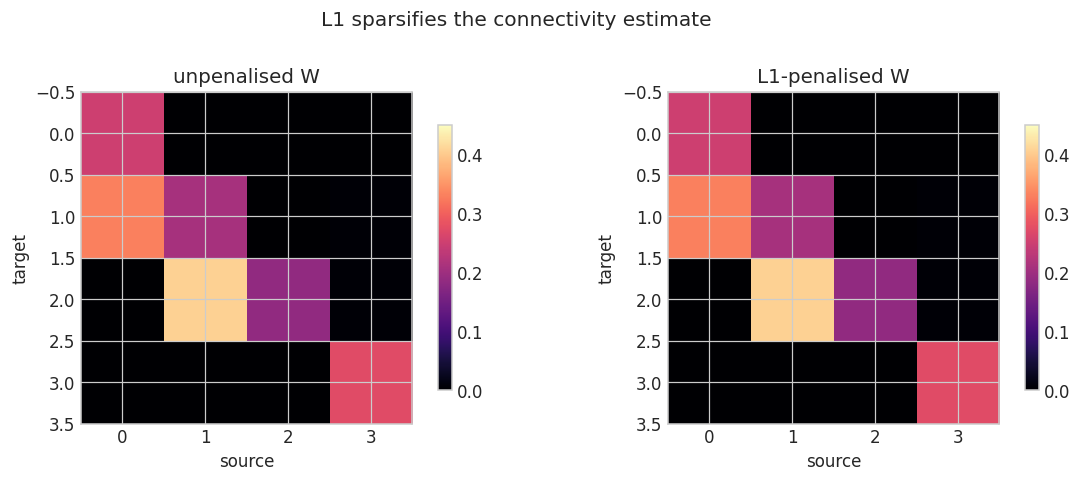

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, mat_, title in [(axes[0], W_plain, "unpenalised"), (axes[1], W_l1, "L1-penalised")]:
    im = ax.imshow(mat_, cmap="magma", vmin=0, vmax=0.45)
    ax.set_title(f"{title} W"); ax.set_xlabel("source"); ax.set_ylabel("target")
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("L1 sparsifies the connectivity estimate", y=1.02)
fig.tight_layout(); plt.show()

## 5. Linear vs nonlinear on the same data
On data with genuine inhibition (Part 2), the nonlinear model should fit far
better than a linear Hawkes, which cannot represent suppression at all.

In [9]:
lin = it.UnivariateHawkes(mu=1.0, kernel=it.ExponentialKernel(alpha=0.2, beta=1.5))
lin_res = lin.fit(ev_inhib, T=1500.0, method="mle")
print(f"{'model':<14}{'loglik':>10}{'AIC':>10}")
print(f"{'linear':<14}{lin_res.log_likelihood:>10.1f}{lin_res.aic:>10.1f}")
print(f"{'nonlinear':<14}{res_nl.log_likelihood:>10.1f}{res_nl.aic:>10.1f}")
print(f"\nDelta AIC = {lin_res.aic - res_nl.aic:.1f} (positive favours nonlinear)")

model             loglik       AIC
linear           -1496.2    2996.4
nonlinear        -1453.3    2912.6

Delta AIC = 83.8 (positive favours nonlinear)


## 6. Optional: Bayesian uncertainty

With the `[bayesian]` extra installed (numpyro), `method="bayesian"` returns
posterior samples instead of a point estimate -- full uncertainty, including
credible intervals and correlations. (Skip this cell if numpyro is absent.)

/home/etrigan/SoftwareDev/Libraries/intensify/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/inference/bayesian.py:81: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  ev = jnp.asarray(np.asarray(events, dtype=float).ravel(), dtype=jnp.float64)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/inference/bayesian.py:16: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  events = jnp.sort(jnp.asarray(events, dtype=jnp.float64))
/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/inference/bayesian.py:17: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  T = jnp.asarray(T, dtype=jnp.float64)
/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/inference/bayesian.py:18: UserWarnin

  0%|          | 0/900 [00:00<?, ?it/s]

warmup:   5%|▌         | 45/900 [00:00<00:10, 81.70it/s, 3 steps of size 6.91e-02. acc. prob=0.75]

warmup:  32%|███▏      | 291/900 [00:00<00:01, 571.23it/s, 7 steps of size 1.20e+00. acc. prob=0.78]

sample:  67%|██████▋   | 607/900 [00:00<00:00, 1159.06it/s, 3 steps of size 8.65e-01. acc. prob=0.89]

sample: 100%|██████████| 900/900 [00:00<00:00, 1093.93it/s, 3 steps of size 8.65e-01. acc. prob=0.90]

posterior means: {'mu': 0.44, 'alpha': 0.313, 'beta': 5.003}


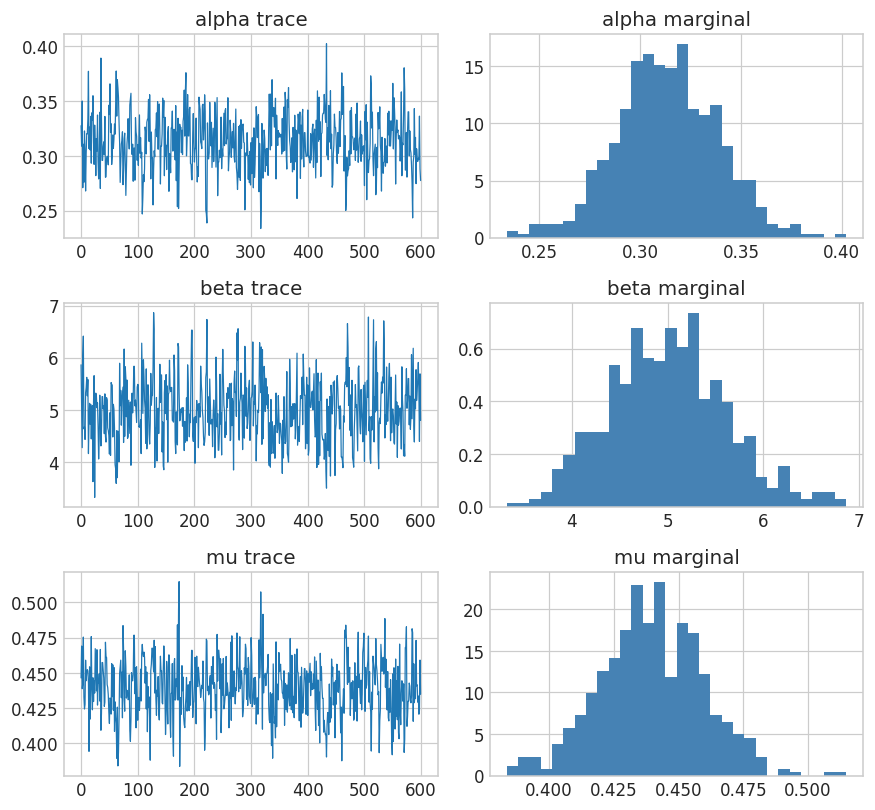

In [10]:
try:
    bx = it.UnivariateHawkes(mu=0.3, kernel=it.ExponentialKernel(alpha=0.3, beta=1.0))
    bres = bx.fit(ev, T=1500.0, method="bayesian")
    post = bres.flat_params()
    print("posterior means:", {k: round(float(v), 3) for k, v in post.items()})
    bres.plot_posterior()
    plt.show()
except Exception as exc:  # numpyro not installed, etc.
    print(f"Bayesian backend unavailable: {type(exc).__name__}: {exc}")

---
### Try it yourself
* Build a 2-D nonlinear model where one stream inhibits another
  (`it.MultivariateNonlinearHawkes`) -- e.g. a predator-prey coupling.
* Refine the nonparametric `edges` and see how bin resolution trades off
  against estimation noise.
* Sweep the L1 `strength` and trace the number of surviving edges
  (a regularisation path).

### Next steps
* **05_lgcp_neuroscience** -- latent-rate (doubly stochastic) processes.
* User guide: [kernels](../docs/user_guide/kernels.md),
  [inference](../docs/user_guide/inference.md).